<center><u><h1>Assignment :-Generative Adversarial Network_GANs</center></u></h1>

![](https://thumbs.gfycat.com/MelodicConventionalGoldenmantledgroundsquirrel.webp)

#Table of content

1. What is a GANs?
2. How does GANs work?
3. Applications of GANs
4. Implementing a GANs

###1.What is a GAN?
Let’s say you are a cricket player and unfortunately you are not good at facing Bouncers. What would you do to overcome this? You would simply ask bowlers to bowl Bouncers in your net sessions to get better at it. You would also observe the batsmen who are good at facing Bouncers. You probably keep practicing and learning from your mistakes. You would repeat this step until you become BEST at facing Bouncers. A similar concept can be incorporated in GANs.

The more you face Bouncers, the better you’ll become at facing Bouncers. But wait, to face more Bouncers, you must have the bowlers who can bowl Bouncers more frequently. So, you become good at facing Bouncers indirectly depends on the bowlers you choose.

**Just to get a Strong Batsmen (generator), we need a powerful Bowler (discriminator)!**

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQm2aOjIxnlvGvmneu2NgML5uRZ79kiCPi2YA&usqp=CAU)

####Technically,<br>
GANs consist of two Artificial Neural Networks or Convolution Neural Networks models namely Generator and Discriminator which are trained against each other


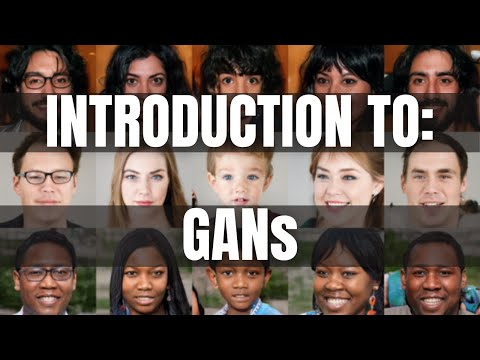

In [2]:
###Refer Video
from IPython.display import YouTubeVideo
YouTubeVideo('OXWvrRLzEaU', width=600, height=300)

##How does GAN work?
Generative Adversarial Networks (GANs) can be divided into three parts:

1. Generative: It describes how data is generated in terms of a probabilistic model.
2. Adversarial:In an Adversarial setting, The training of model is done.
3. Networks: Use deep neural networks as the algorithms for training purpose.


GANs consists of two ANN or CNN models:
1. Generator Model: Used to generate new images which look like real images.
2. Discriminator Model: Used to classify images as real or fake.


### Generator
The main goal of the Generator is to fool the Discriminator by generating images that look like real images and thus makes it harder for the Discriminator to classify images as real or fake.

### Discriminator
The Discriminator Model takes an image as an input (generated and real) and classifies it as real or fake.
The discriminator model is the simple binary classification model.




![](https://www.researchgate.net/publication/335199153/figure/fig1/AS:792329124339712@1565917392960/Architecture-of-the-GAN-22.ppm)

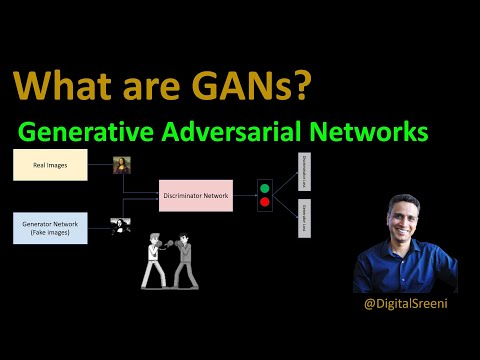

In [3]:
###Refer Video
YouTubeVideo('xBX2VlDgd4I', width=600, height=300)

Here,Architecture of the generative model captures the distribution of data and is trained in such a manner that it tries to maximize the probability of the Discriminator in making a mistake.<br>
The Discriminator, on the other hand, is based on a model that estimates the probability that the sample that it got is received from the training data and not from the Generator.<br>
The GANs are formulated as a minimax game, where the Discriminator is trying to minimize its reward V(D, G) and the Generator is trying to minimize the Discriminator’s reward.

![](https://editor.analyticsvidhya.com/uploads/26563gan-equation.png)

where,
G = Generator,<br>
D = Discriminator,<br>
Pdata(x) = distribution of real data,<br>
P(z) = distribution of generator,<br>
x = sample from Pdata(x),<br>
z = sample from P(z),<br>
D(x) = Discriminator network,<br>
G(z) = Generator network.

<br>

The Discriminator is trained while the Generator is idle. In this phase, the network is only forward propagated and no back-propagation is done. The Discriminator is trained on real data for n epochs, and see if it can correctly predict them as real. Also,the Discriminator is also trained on the fake generated data from the Generator and see if it can correctly predict them as fake.<br>
<br>
The Generator is trained while the Discriminator is idle. After the Discriminator is trained by the generated fake data of the Generator, we can get its predictions and use the results for training the Generator and get better from the previous state to try and fool the Discriminator.

##Different types of GANs:
1. **Vanilla GAN:** This is the simplest type GAN. The Generator and the Discriminator are simple multi-layer perceptrons.
2. **Conditional GAN (CGAN):** CGAN can be described as a deep learning method in which some conditional parameters are put into place. In CGAN, an additional parameter ‘y’ is added to the Generator for generating the corresponding data.
3. **Deep Convolutional GAN (DCGAN):** DCGAN is one of the most popular also the most successful implementation of GAN. It is composed of ConvNets in place of multi-layer perceptrons.
4. **Laplacian Pyramid GAN (LAPGAN):** The Laplacian pyramid is a linear invertible image representation consisting of a set of band-pass images, spaced an octave apart, plus a low-frequency residual.This approach uses multiple numbers of Generator and Discriminator networks and different levels of the Laplacian Pyramid.
5. Super Resolution GAN (SRGAN): SRGAN as the name suggests is a way of designing a GAN in which a deep neural network is used along with an adversarial network in order to produce higher resolution images.

Applications of GANs

1. Image to Image Translation

![](https://editor.analyticsvidhya.com/uploads/73176img-to-img-translation.PNG)

2. Text to Image Translation

![](https://editor.analyticsvidhya.com/uploads/37782text-image-translation.PNG)

3. Photos to Emojis

![](https://editor.analyticsvidhya.com/uploads/12712photos-to-emoji.PNG)

###Implementing a GANs
For our example, we will be using the famous MNIST dataset and use it to produce a clone of a random digit. The MNIST database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems.

![mnist.png](https://upload.wikimedia.org/wikipedia/commons/thumb/2/27/MnistExamples.png/320px-MnistExamples.png)

Our model will create replicas of these digits by passing random data into it.<br>
To begin, you need to install torchvision. Torchvision is a Computer Vision library that works hand in hand with PyTorch. It includes tools for doing efficient image and video transformations, as well as pre-trained models and datasets.

In [4]:
#install torchvision==0.5.0
!pip install torch torchvision

Next we will import the necessary libraries.<br>
* torch: for implementing deep neural networks
* torch.nn: torch.nn module helps in creating and training of the neural network.
* math: for mathematical tasks
* matplotlib: for visualizations
* torchvision: for computer vision taks using pytorch
* torchvision.transforms: for image transformations.


In [5]:
# import the mentioned libraries
import torch
from torch import nn
import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms




To be able to duplicate the experiment, set up the random generator seed. This will generate the same fixed number of random numbers whenever we create random numbers.Know about manual seed: https://discuss.pytorch.org/t/what-is-manual-seed/5939

In [6]:
#set the seed to 111
torch.manual_seed(111)

Because the training data in this case involves photos, the models must be more complicated, with a larger number of parameters. When running on CPU, this slows down the training process, which takes roughly two minutes every epoch. To get a relevant result, you'll need roughly fifty epochs, thus total training time on a CPU is around one hundred minutes.

If you have one, you can use a GPU to train the model to shorten the training time. Change the hardware accelerator to GPU in the runtime settings. We check the GPU in the next part.

In [7]:
# check the GPU
# copy the code
device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('using gpu')
else:
    device = torch.device("cpu")
    print('using cpu')

using gpu


The MNIST dataset is made up of 28 pixel grayscale photographs of handwritten numbers ranging from 0 to 9. You'll need to convert them before you can utilise them with PyTorch. You do this by defining transform, a function that will be used to load the data.<br>
The function has two parts:

1. transforms.ToTensor() converts the data to a PyTorch tensor.
2. transforms.Normalize() converts the range of the tensor coefficients.

In [8]:
#create the transform and use compose method
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

Transforms provide the original coefficients. Because the image backgrounds are black, the ToTensor() range is 0 to 1, and most of the coefficients are equal to 0 when expressed using this range. By subtracting 0.5 from the original coefficients and dividing the result by 0.5, transforms.Normalize() alters the range of the coefficients to -1 to 1. The number of elements equal to 0 in the input samples is drastically reduced as a result of this modification, which aids in model training.
The transform parameters.
(M1,..., Mn) and (S1,..., Sn) are two tuples in Normalize(), with n denoting the number of channels in the images. Because grayscale images with only one channel, such as those in the MNIST collection, have only one value, the tuples have only one value.

The image is then transformed for each channel i transforms.Normalize() takes the coefficients and subtracts Mi from them, then divides the result by Si.

You may now use torchvision.datasets.MNIST to load the training data and use transform to execute the conversions.

In [9]:
# prepare the training data by applying conversions on mnist dataset
train_set=torchvision.datasets.MNIST(
    root='.',train=True,download=True,transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


The option download=True ensures that the MNIST dataset is downloaded and placed in the current directory, as indicated by the argument root, the first time you run the above code.
<br><br>
Next, Create a data loader called train loader to shuffle the data from train set and return batches of 32 samples to train the neural networks.

In [10]:
#set batch size to 32
batch_size=32
#create the data loader
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
#refer the above code


Matplotlib can be used to plot some training data samples. You may use cmap=gray r to reverse the colour map and plot the digits in black on a white background to improve the visualisation

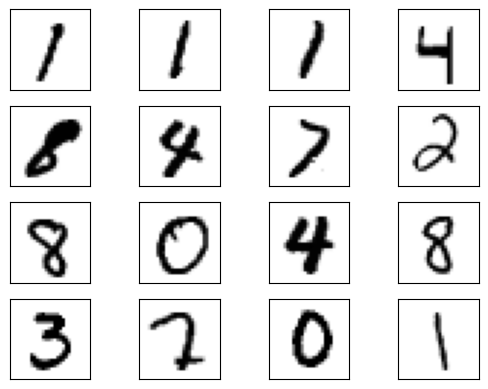

In [11]:
# get the samples from train_loader
real_samples,mnist_labels=next(iter(train_loader))
#run for loop
for i in range(16):
    #create subplots
  ax=plt.subplot(4,4,i+1)    #plot the samples,keep cmap as gray_r
  plt.imshow(real_samples[i].reshape(28,28),cmap='gray_r')
    #plot xticks
  plt.xticks([])
    #plot yticks
  plt.yticks([])


You can use the discriminator and generator models now that you've prepared the training data. The discriminator in this scenario is an MLP neural network that receives a 28 pixel picture and returns the likelihood that the image belongs to the real training data.

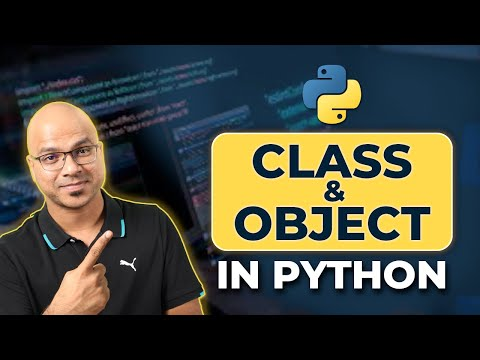

In [12]:
###refer Video for Object oriented prgramming in python
YouTubeVideo('8O5kX73OkIY', width=600, height=300)

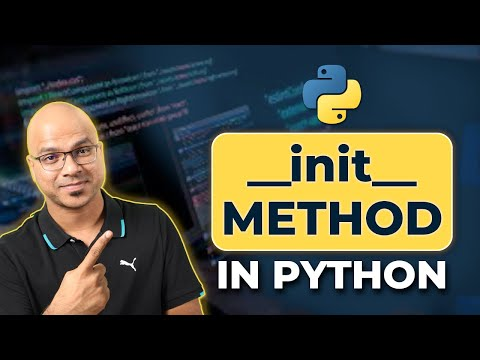

In [13]:
###refer Video for Object oriented prgramming in python
YouTubeVideo('WIP3-woodlU', width=600, height=300)

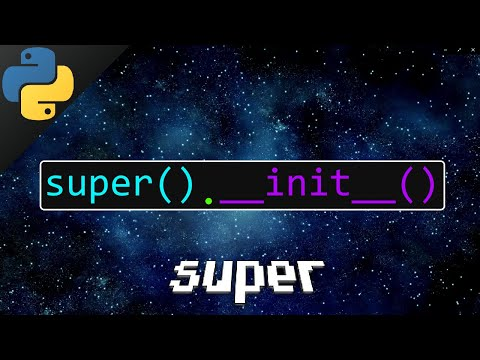

In [14]:
###refer Video for Object oriented prgramming in python
YouTubeVideo('MBbVq_FIYDA', width=600, height=300)

In [15]:
import torch
import torch.nn as nn

# create discriminator class
class Discriminator(nn.Module):

    # define init function
    def __init__(self):

        # call parent constructor
        super().__init__()

        # create sequential model
        self.model = nn.Sequential(

            # input layer
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            # hidden layer
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # hidden layer
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # output layer
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    # forward function
    def forward(self, x):

        # convert 28x28 image into 784 vector
        x = x.view(x.size(0), 784)

        # pass through model
        output = self.model(x)

        return output

You use .__init__() to build the model. First, you need to call super().__init__() to run .__init__() from nn.Module. The discriminator you’re using is an MLP neural network defined in a sequential way using nn.Sequential(). It has the following characteristics:

* **Lines 5 and 6:** The input is two-dimensional, and the first hidden layer is composed of 256 neurons with ReLU activation.

* **Lines 8, 9, 11, and 12:** The second and third hidden layers are composed of 128 and 64 neurons, respectively, with ReLU activation.

* **Lines 14 and 15:** The output is composed of a single neuron with sigmoidal activation to represent a probability.

* **Lines 7, 10, and 13:** After the first, second, and third hidden layers, you use dropout to avoid overfitting.

Finally,.forward() is used to describe how the model's output is calculated. The model's input, which is a two-dimensional tensor, is represented by x. The result is obtained in this implementation by feeding the input x into the model you've built without any extra processing. The vectorization occurs in the first line of .forward(), as the call to x.view() converts the shape of the input tensor. In this case, the original shape of the input x is 32 × 1 × 28 × 28, where 32 is the batch size you’ve set up. After the conversion, the shape of x becomes 32 × 784, with each line representing the coefficients of an image of the training set.

To use the GPU to run the discriminator model, you must first create it and then transfer it to the GPU using the.to command (). You can send the model to the device object you generated before to use a GPU when one is available.

In [16]:
#create discriminator object and transfer to GPU
discriminator = Discriminator().to(device=device)

Because the generator will be producing increasingly complicated data, the dimensions of the input from the latent space must be increased. In this scenario, the generator will receive a 100-dimensional input and produce an output with 784 coefficients grouped in a 28-28 tensor that represents a picture.

<br>The generator in generative adversarial networks is the model that accepts samples from a latent space as input and produces data that is similar to the data in the training set. It's a model with a two-dimensional input that will receive random points (z1, z2) and a two-dimensional output that must supply (x1, x2) values that are similar to those from the training data in this case.

The implementation is comparable to the discriminator you created. To define the neural network architecture, first construct a Generator class that derives from nn.Module, and then instantiate a Generator object:

In [17]:
import torch
import torch.nn as nn

# create generator class
class Generator(nn.Module):

    # define init function
    def __init__(self):

        # call parent constructor
        super().__init__()

        # create sequential model
        self.model = nn.Sequential(

            # input layer
            nn.Linear(100, 256),
            nn.ReLU(),

            # hidden layer
            nn.Linear(256, 512),
            nn.ReLU(),

            # hidden layer
            nn.Linear(512, 1024),
            nn.ReLU(),

            # output layer
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    # forward function
    def forward(self, x):

        # pass through model
        output = self.model(x)

        # reshape into image format
        output = output.view(x.size(0), 1, 28, 28)

        return output


# create generator object and transfer to GPU
generator = Generator().to(device=device)

The generator neural network is represented by the word generator. It has two hidden layers with 16 and 32 neurons, both with ReLU activation, and an output linear activation layer with 2 neurons. As a result, the output will be a vector with two members that can be any value between negative infinity and infinite, representing (x1, x2).

After you've defined the models, you'll use the training data to train them.<br><br>
Here you set up the following parameters:

* Line 1 sets the learning rate (lr), which you’ll use to adapt the network weights.

* Line 2 sets the number of epochs (num_epochs), which defines how many repetitions of training using the whole training set will be performed.

* Line 3 assigns the variable loss_function to the binary cross-entropy function BCELoss(), which is the loss function that you’ll use to train the models.

We will add Adam optimizer to both the discriminator and the generator.

In [21]:
import torch.nn as nn
import torch.optim as optim

# set learning rate
lr = 0.0001

# set number of epochs
num_epochs = 5


# set loss function
loss_function = nn.BCELoss()

# add optimizer to the discriminator
optimizer_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=lr
)

# add optimizer to the generator
optimizer_generator = optim.Adam(
    generator.parameters(),
    lr=lr
)

Now its time to train the model.

In [22]:
# run for loop with number of epochs
for epoch in range(num_epochs):

    # run for loop by getting real samples from the data loader
    for n, (real_samples, _) in enumerate(train_loader):

        # =========================================
        # TRAINING THE DISCRIMINATOR
        # =========================================

        # send real samples to GPU/CPU
        real_samples = real_samples.to(device=device)

        # create labels for real samples (1 = real)
        real_samples_labels = torch.ones(
            (real_samples.size(0), 1)
        ).to(device=device)

        # create random latent vectors
        latent_space_samples = torch.randn(
            (real_samples.size(0), 100)
        ).to(device=device)

        # generate fake images
        generated_samples = generator(latent_space_samples)

        # create labels for fake samples (0 = fake)
        generated_samples_labels = torch.zeros(
            (real_samples.size(0), 1)
        ).to(device=device)

        # concatenate real and fake samples
        all_samples = torch.cat(
            (real_samples, generated_samples)
        )

        # concatenate labels
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # clear gradients
        discriminator.zero_grad()

        # discriminator predictions
        output_discriminator = discriminator(all_samples)

        # discriminator loss
        loss_discriminator = loss_function(
            output_discriminator,
            all_samples_labels
        )

        # backpropagation
        loss_discriminator.backward()

        # update discriminator weights
        optimizer_discriminator.step()

        # =========================================
        # TRAINING THE GENERATOR
        # =========================================

        # create random latent vectors
        latent_space_samples = torch.randn(
            (real_samples.size(0), 100)
        ).to(device=device)

        # clear gradients
        generator.zero_grad()

        # generate fake images
        generated_samples = generator(latent_space_samples)

        # discriminator prediction on fake images
        output_discriminator_generated = discriminator(
            generated_samples
        )

        # generator wants discriminator to output 1
        loss_generator = loss_function(
            output_discriminator_generated,
            real_samples_labels
        )

        # backpropagation
        loss_generator.backward()

        # update generator weights
        optimizer_generator.step()

    # =========================================
    # SHOW LOSSES
    # =========================================

    print(f"Epoch: {epoch}")
    print(f"Loss D.: {loss_discriminator}")
    print(f"Loss G.: {loss_generator}")

Epoch: 0
Loss D.: 0.5583925843238831
Loss G.: 1.2356016635894775
Epoch: 1
Loss D.: 0.6154146194458008
Loss G.: 1.1729621887207031
Epoch: 2
Loss D.: 0.5947632789611816
Loss G.: 0.9944952726364136
Epoch: 3
Loss D.: 0.4815158545970917
Loss G.: 1.034423589706421
Epoch: 4
Loss D.: 0.5817436575889587
Loss G.: 1.4361885786056519


At each training iteration for GANs, the discriminator and generator parameters are updated. The training process is divided into two loops, one for the training epochs and the other for the batches for each epoch, as it is for all neural networks. You begin preparing the data for training the discriminator inside the inner loop:<br><br>
* **Line 2:** You get the real samples of the current batch from the data loader and assign them to real_samples. Notice that the first dimension of the tensor has the number of elements equal to batch_size. This is the standard way of organizing data in PyTorch, with each line of the tensor representing one sample from the batch.

* **Line 4:** You use torch.ones() to create labels with the value 1 for the real samples, and then you assign the labels to real_samples_labels.

* **Lines 5 and 6:** You create the generated samples by storing random data in latent_space_samples, which you then feed to the generator to obtain generated_samples.

* **Line 7:** You use torch.zeros() to assign the value 0 to the labels for the generated samples, and then you store the labels in generated_samples_labels.

* **Lines 8 to 11:** You concatenate the real and generated samples and labels and store them in all_samples and all_samples_labels, which you’ll use to train the discriminator.

Next, in lines 14 to 19, you train the discriminator:

* **Line 14:** In PyTorch, it’s necessary to clear the gradients at each training step to avoid accumulating them. You do this using .zero_grad().

* **Line 15:** You calculate the output of the discriminator using the training data in all_samples.

* **Lines 16 and 17:** You calculate the loss function using the output from the model in output_discriminator and the labels in all_samples_labels.

* **Line 18:** You calculate the gradients to update the weights with loss_discriminator.backward().

* **Line 19:** You update the discriminator weights by calling optimizer_discriminator.step().

Next, in **line 22**, you prepare the data to train the generator. You store random data in latent_space_samples, with a number of lines equal to batch_size. You use two columns since you’re providing two-dimensional data as input to the generator.

You train the generator in lines 25 to 32:

* **Line 25:** You clear the gradients with .zero_grad().

* **Line 26:** You feed the generator with latent_space_samples and store its output in generated_samples.

* **Line 27:** You feed the generator’s output into the discriminator and store its output in output_discriminator_generated, which you’ll use as the output of the whole model.

* **Lines 28 to 30:** You calculate the loss function using the output of the classification system stored in output_discriminator_generated and the labels in real_samples_labels, which are all equal to 1.

* **Lines 31 and 32:** You calculate the gradients and update the generator weights. Remember that when you trained the generator, you kept the discriminator weights frozen since you created optimizer_generator with its first argument equal to generator.parameters().

Finally, on **lines 35 to 37**, you display the values of the discriminator and generator loss functions at the end of each ten epochs.

To generate handwritten digits, you have to take some random samples from the latent space and feed them to the generator:

In [23]:
# take random samples from latent space
latent_space_samples = torch.randn(16, 100).to(device=device)

# pass random samples to the generator
generated_samples = generator(latent_space_samples)

If generated samples is executing on the GPU, you must transport the data back

1.   List item
2.   List item

to the CPU to plot it. To do so, simply type.cpu in the command prompt (). You must also call.detach() before using Matplotlib to plot the data.

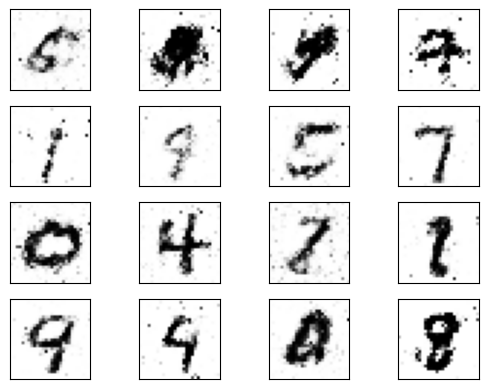

In [24]:
import matplotlib.pyplot as plt

# send generated samples to CPU
generated_samples = generated_samples.cpu().detach()

# run loop
for i in range(16):

    # create subplot
    plt.subplot(4, 4, i + 1)

    # show generated image
    plt.imshow(
        generated_samples[i].reshape(28, 28),
        cmap="gray_r"
    )

    # remove x ticks
    plt.xticks([])

    # remove y ticks
    plt.yticks([])

# show all images
plt.show()

Hence, our GAN has created handwritten digits replicating digist from the MNIST dataset.

In this tutorial, you learned:

* What the difference is between discriminative and generative models
* How generative adversarial networks are structured and trained
* How to use tools like PyTorch and a GPU to implement and train GAN models

We have come to an end of this project but don't stop here, try as many projects of the similar type to get a better understanding of the use cases.
Solve the practice sheet of this project to test yourself.!!


Great job!! You have come to the end of this assignment. Treat yourself for this :))
<br>
# Do fill this [feedback form](https://forms.zohopublic.in/cloudyml/form/CloudyMLDeepLearningFeedbackForm/formperma/VCFbldnXAnbcgAIl0lWv2blgHdSldheO4RfktMdgK7s)
<br>
You may head on to the next assignment.

![](https://www.funimada.com/assets/images/cards/big/thank-you-9.gif)